# Генеративті қарсыластар желілері (GAN)

**Тақырып:** Генеративті модельдеу негіздері.

Бұл зертханалық жұмыста біз 2014 жылы Ян Гудфеллоу ұсынған **GAN (Generative Adversarial Networks)** архитектурасымен танысамыз.

**Мақсаты:**
Шынайы деректерге (мысалы, қолжазба сандарға) ұқсайтын жаңа, жасанды деректерді жасауды үйрену.


## 1. GAN теориясы: "Ұры мен Полицей" ойыны

GAN екі нейрондық желінің бәсекелестігіне негізделген:

1.  **Генератор (Generator - $G$):** "Ұры". Оның мақсаты — кездейсоқ шудан (noise) жалған суреттер жасап, Дискриминаторды алдау.
2.  **Дискриминатор (Discriminator - $D$):** "Полицей". Оның мақсаты — алдына келген суреттің **шынайы** (dataset-тен) немесе **жалған** (генератордан) екенін анықтау.

Оқыту барысында екеуі де дамиды: "ұры" сапалырақ жасай бастайды, ал "полицей" жақсырақ тексере бастайды. Тепе-теңдік орнағанда (Nash Equilibrium), біз сапалы генеративті модель аламыз.


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Графиктер стилі (сіздің қалауыңыз бойынша ашық көк түс)
plt.style.use('seaborn-v0_8-whitegrid')
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

# Құрылғыны таңдау
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Жұмыс құрылғысы: {device}")

# Гиперпараметрлер
latent_dim = 100  # Генераторға кіретін кездейсоқ вектор өлшемі
lr = 0.0002       # Оқыту жылдамдығы
batch_size = 64   # Пакет өлшемі
num_epochs = 50   # Дәуір саны (сабақта көрсету үшін аз алынды)

Жұмыс құрылғысы: cuda



## 2. Деректерді дайындау (MNIST)

Біз `torchvision` кітапханасы арқылы MNIST датасетін жүктейміз. Бұл деректер қарапайым (ақ-қара түсті), сондықтан модель тез оқытылады.


DataLoader құру.

In [2]:
# Суреттерді түрлендіру: Тензорға айналдыру және нормализация (-1 мен 1 аралығына)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Датасетті жүктеу
dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                     transform=transform, download=True)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Жалпы сурет саны: {len(dataset)}")

100%|██████████| 9.91M/9.91M [00:08<00:00, 1.17MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 97.1kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 861kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]

Жалпы сурет саны: 60000



## 3. Генератор және Дискриминатор кластарын құру

Біз күрделі емес, толық байланысқан (Fully Connected) желілерді қолданамыз.
* **Generator:** `Latent Vector (100)` $\rightarrow$ `Image (784 пиксель)`
* **Discriminator:** `Image (784 пиксель)` $\rightarrow$ `Probability (0 немесе 1)`

Желі архитектурасын кодтау.

In [3]:
# Генератор класы
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            # 1-қабат: Шудан жасырын қабатқа
            nn.Linear(latent_dim, 256),
            nn.ReLU(True),
            # 2-қабат
            nn.Linear(256, 512),
            nn.ReLU(True),
            # 3-қабат
            nn.Linear(512, 1024),
            nn.ReLU(True),
            # Шығыс қабат: 28x28 = 784 пиксель
            nn.Linear(1024, 784),
            nn.Tanh() # Шығыс мәндері -1 мен 1 аралығында болуы керек
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 1, 28, 28) # Сурет пішініне келтіру
        return img

# Дискриминатор класы
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), # Суретті векторға айналдыру
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2, inplace=True), # LeakyReLU GAN үшін жақсы жұмыс істейді
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid() # Ықтималдық (0 = жалған, 1 = шынайы)
        )

    def forward(self, img):
        validity = self.model(img)
        return validity

# Модельдерді инициализациялау
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Қателік функциясы (Binary Cross Entropy)
criterion = nn.BCELoss()

# Оптимизаторлар (Adam)
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

## 4. Оқыту процесі (Training Loop)

Бұл GAN-ның ең маңызды бөлігі. Әр қадамда біз:
1.  **Дискриминаторды оқытамыз:**
    * Шынайы суреттерді көрсетіп, `1` деп белгілейміз.
    * Генератордан жалған сурет жасатып, оны `0` деп белгілейміз.
    * Дискриминатор айырмашылықты тануды үйренеді.
2.  **Генераторды оқытамыз:**
    * Жалған суреттерді қайта жасап, Дискриминаторға көрсетеміз.
    * Бірақ бұл жолы мақсатты `1` (шынайы) деп белгілейміз.
    * Генератор дискриминаторды "алдауды" үйренеді (яғни, дискриминатор қателесіп `1` деуі керек).



Оқыту циклін іске қосу.

In [7]:
print("Оқыту басталды...")

for epoch in range(num_epochs):
    for i, (imgs, _) in enumerate(dataloader):

        # Шынайы суреттерді дайындау
        real_imgs = imgs.to(device)
        # Белгілер (Labels): Real = 1, Fake = 0
        real_labels = torch.ones(imgs.size(0), 1).to(device)
        fake_labels = torch.zeros(imgs.size(0), 1).to(device)

        # -----------------
        # 1. Дискриминаторды оқыту
        # -----------------
        optimizer_D.zero_grad()

        # Шынайы суреттер бойынша қателік (Loss)
        outputs = discriminator(real_imgs)
        d_loss_real = criterion(outputs, real_labels)

        # Жалған суреттерді генерациялау
        z = torch.randn(imgs.size(0), latent_dim).to(device) # Шу
        fake_imgs = generator(z)

        # Жалған суреттер бойынша қателік (Loss)
        outputs = discriminator(fake_imgs.detach()) # .detach() генераторды өзгертпеу үшін керек
        d_loss_fake = criterion(outputs, fake_labels)

        # Жалпы қателік
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        # -----------------
        # 2. Генераторды оқыту
        # -----------------
        optimizer_G.zero_grad()

        # Генератордың мақсаты - дискриминаторды алдау (output 1 болуы керек)
        outputs = discriminator(fake_imgs)
        g_loss = criterion(outputs, real_labels) # Назар аударыңыз: мұнда real_labels қолданамыз!

        g_loss.backward()
        optimizer_G.step()

    # Нәтижені шығару
    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Оқыту басталды...
Epoch [5/20] | D Loss: 0.8887 | G Loss: 2.3104
Epoch [10/20] | D Loss: 0.9522 | G Loss: 3.2891
Epoch [15/20] | D Loss: 0.7874 | G Loss: 1.9707
Epoch [20/20] | D Loss: 1.1799 | G Loss: 1.9088
Epoch [25/20] | D Loss: 0.7947 | G Loss: 2.0065
Epoch [30/20] | D Loss: 0.7295 | G Loss: 1.9484
Epoch [35/20] | D Loss: 1.1700 | G Loss: 1.2135
Epoch [40/20] | D Loss: 1.2169 | G Loss: 1.2469
Epoch [45/20] | D Loss: 1.2552 | G Loss: 1.1311
Epoch [50/20] | D Loss: 1.2404 | G Loss: 0.9876



## 5. Нәтижелерді тексеру

Оқытылған Генератор моделі кездейсоқ шудан қандай суреттер жасайтынын көрейік.


 Соңғы нәтижені көрсету.

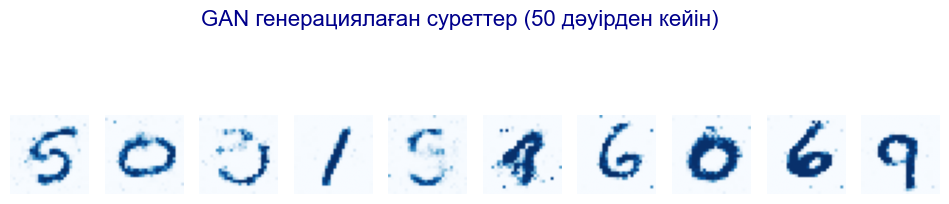

In [13]:
# Генераторды бағалау режиміне көшіру
generator.eval()

# Жаңа шу генерациялау
z = torch.randn(10, latent_dim).to(device)

# Суреттерді жасау
with torch.no_grad():
    generated_imgs = generator(z).cpu()

# Визуализация (Skyblue стилінде)
plt.figure(figsize=(12, 3))
for i in range(10):
    ax = plt.subplot(1, 10, i+1)
    # Суретті (28, 28) форматына келтіру
    img = generated_imgs[i].view(28, 28)
    plt.imshow(img, cmap='Blues') # Студенттерге қызықты болу үшін көк түспен
    plt.axis('off')

    # Жақтауын әдемілеу
    for spine in ax.spines.values():
        spine.set_edgecolor('skyblue')
        spine.set_linewidth(2)

plt.suptitle(f"GAN генерациялаған суреттер ({num_epochs} дәуірден кейін)", fontsize=16, color='darkblue')
plt.show()


## Қорытынды және Талқылау

Бұл тәжірибеде біз:
1.  **Генератор** мен **Дискриминатор** қалай бір-бірімен "бәсекелесетінін" көрдік.
2.  Бастапқыда шу (noise) болған деректердің бірте-бірте сандарға ұқсай бастағанын байқадық.

**Өз бетімен жұмыс:**
* Оқыту дәуірін (epochs) 50-ге дейін көтеріп көріңіз. Сапасы қалай өзгереді?
* `Batch_size` параметрін өзгертсе, оқыту жылдамдығына қалай әсер етеді?



**Қосымша кеңес:**  GAN оқыту кейде тұрақсыз (unstable) болады. Кейде генератор дискриминаторды тым тез алдап үйреніп алады да, бірдей суреттерді шығара береді (Mode Collapse). Бұл - қалыпты жағдай және оны шешу жеке зерттеу тақырыбы.